In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:42149")
client

<Client: 'tcp://127.0.0.1:42149' processes=9 threads=72, memory=136.41 GiB>

In [2]:
import xarray as xr
import numpy as np
import os.path as op
import tripyview as tpv
import gsw
import matplotlib.pyplot as plt

# xr.set_options(keep_attrs=True)
# do_parallel       = True
# parallel_nprc     = 16   # number of dask workers
# parallel_nprc_bin = 8   # number of processor used to parallize the binning loop
# parallel_tmem     = 256   # max. available RAM

%matplotlib inline

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
ddir = "/work/uo0119/a270067/runtime/awicm3-v3.1/"
sdir = "/scratch/b/b383315/"
wdir = "/work/ba1254/b383315/fesom2/next/"

In [5]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1e-6
cmax      = 1e-6

cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     ) 

In [6]:
NXX = 48
ds1 = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/unod.fesom.2000.nc"
                              % NXX),
                     chunks={"nz1":1,"x":100000}
                    )
ds = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/w.fesom.2000.nc"
                             % NXX),
                     chunks={"nz":1,"x":100000}
                    )
ds1, ds

(<xarray.Dataset> Size: 29GB
 Dimensions:  (time: 12, nz1: 47, x: 12952215)
 Coordinates:
   * time     (time) datetime64[ns] 96B 2000-01-31T23:57:00 ... 2000-12-31T23:...
   * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
 Dimensions without coordinates: x
 Data variables:
     unod     (time, nz1, x) float32 29GB dask.array<chunksize=(1, 1, 100000), meta=np.ndarray>
 Attributes: (12/21)
     CDI:                                 Climate Data Interface version 2.2.4...
     Conventions:                         CF-1.6
     FESOM_model:                         FESOM2
     FESOM_website:                       fesom.de
     FESOM_git_SHA:                       e23bc823
     FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
     ...                                  ...
     FESOM_evp_rheol_steps:               120
     FESOM_opt_visc:                      7
     FESOM_use_wsplit:                    -1
     FESOM_autorotate_back_to_geo: 

In [7]:
iz2000 = 31
iz4300 = 40
dz = xr.DataArray(np.diff(ds.nz), dims=["nz1"],
                  coords={"nz1":ds1.nz1}
                 ).isel(nz1=slice(None,iz4300))
dz

<xarray.DataArray (nz1: 40)> Size: 320B
array([  5.,   5.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        15.,  20.,  25.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 170., 200., 220., 230., 250., 250.,
       250., 250., 250., 250., 250., 250., 250.])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03

In [8]:
dt = 180. # 3 minutes

mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
                            do_info=True, do_pickle=False
                           )
mesh

 > load mesh from *.out files: /work/ab0995/a270067/fesom2/next/mesh
 > load e_area from fesom.mesh.diag.nc
 > load n_area from fesom.mesh.diag.nc
 > compute lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_pbnd.shp
 > augment lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_focus=0.shp
___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________


___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________

In [9]:
ystart = 2090
NXX = 50

JFMJAS = np.concatenate((np.arange(1,4, dtype=int),
                         np.arange(7,10, dtype=int)))

for yy in range(ystart,2101):
    if yy == ystart: 
        JFM50 = xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,1))
                            )
        JFM50 = xr.concat([JFM50,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,2))
                            )
                          ], "time")
        JFM50 = xr.concat([JFM50,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,3))
                            )
                          ], "time")
        JAS50 = xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,7))
                            )
        JAS50 = xr.concat([JAS50,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,8))
                            )
                          ], "time")
        JAS50 = xr.concat([JAS50,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,9))
                            )
                          ], "time")
    else:
        tmp = xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,1))
                            )
        tmp = xr.concat([tmp,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,2))
                            )
                          ], "time")
        tmp = xr.concat([tmp,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,3))
                            )
                          ], "time")
        JFM50 = xr.concat([JFM50, tmp], "time")
        del tmp
        tmp = xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,7))
                            )
        tmp = xr.concat([tmp,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,8))
                            )
                          ], "time")
        tmp = xr.concat([tmp,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,9))
                            )
                          ], "time")
        JAS50 = xr.concat([JAS50, tmp], "time")
        del tmp
            
print(JFM50, JAS50)
JFM50 = JFM50.mean("time",skipna=True)
JAS50 = JAS50.mean("time",skipna=True)

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 33, nod2: 12952215)
Dimensions without coordinates: time, nod2
Data variables:
    WpRHOpH  (time, nod2) float64 3GB dask.array<chunksize=(1, 100000), meta=np.ndarray> <xarray.Dataset> Size: 3GB
Dimensions:  (time: 33, nod2: 12952215)
Dimensions without coordinates: time, nod2
Data variables:
    WpRHOpH  (time, nod2) float64 3GB dask.array<chunksize=(1, 100000), meta=np.ndarray>


In [10]:
ystart = 2000
NXX = 48

JFMJAS = np.concatenate((np.arange(1,4, dtype=int),
                         np.arange(7,10, dtype=int)))

for yy in range(ystart,2011):
    if yy == ystart: 
        JFM48 = xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,1))
                            )
        JFM48 = xr.concat([JFM48,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,2))
                            )
                          ], "time")
        JFM48 = xr.concat([JFM48,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,3))
                            )
                          ], "time")
        JAS48 = xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,7))
                            )
        JAS48 = xr.concat([JAS48,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,8))
                            )
                          ], "time")
        JAS48 = xr.concat([JAS48,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,9))
                            )
                          ], "time")
        # JFM48.WpRHOpH.isel(nod2=slice(None,10000)).plot()
        # plt.show()
    else:
        tmp = xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,1))
                            )
        tmp = xr.concat([tmp,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,2))
                            )
                          ], "time")
        tmp = xr.concat([tmp,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,3))
                            )
                          ], "time")
        # tmp.WpRHOpH.mean("time").isel(nod2=slice(None,10000)).plot()
        # plt.show()
        JFM48 = xr.concat([JFM48, tmp], "time")
        del tmp
        tmp = xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,7))
                            )
        tmp = xr.concat([tmp,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,8))
                            )
                          ], "time")
        tmp = xr.concat([tmp,
                           xr.open_zarr(op.join(wdir,"ppdwp/N%2d/MLD3/ppdwp_%4d-%02d.zarr" 
                                     % (NXX,yy,9))
                            )
                          ], "time")
        JAS48 = xr.concat([JAS48, tmp], "time")
        del tmp
            
print(JFM48, JAS48)
JFM48 = JFM48.mean("time",skipna=True)
JAS48 = JAS48.mean("time",skipna=True)

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 33, nod2: 12952215)
Dimensions without coordinates: time, nod2
Data variables:
    WpRHOpH  (time, nod2) float64 3GB dask.array<chunksize=(1, 100000), meta=np.ndarray> <xarray.Dataset> Size: 3GB
Dimensions:  (time: 33, nod2: 12952215)
Dimensions without coordinates: time, nod2
Data variables:
    WpRHOpH  (time, nod2) float64 3GB dask.array<chunksize=(1, 100000), meta=np.ndarray>


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1.6e-07, 'cmax': 1.6e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7fff61bf6000>, 'clevel': array([-1.60e-07, -1.55e-07, -1.50e-07, -1.45e-07, -1.40e-07, -1.35e-07,
       -1.30e-07, -1.25e-07, -1.20e-07, -1.15e-07, -1.10e-07, -1.05e-07,
       -1.00e-07, -9.50e-08, -9.00e-08, -8.50e-08, -8.00e-08, -7.50e-08,
       -7.00e-08, -6.50e-08, -6.00e-08, -5.50e-08, -5.00e-08, -4.50e-08,
       -4.00e-08, -3.50e-08, -3.00e-08, -2.50e-08, -2.00e-08, -1.50e-08,
       -1.00e-08, -5.00e-09,  0.00e+00,  5.00e-09,  1.00e-08,  1.50e-08,
        2.00e-08,  2.50e-08,  3.00e-08,  3.50e-08,  4.00e-08,  4.50e-08,
        5.00e-08,  5.50e-08,  6.00e-08,  6.50e-08,  7.00e-08,  7.50e-08,
        8.00e-08,  8.50e-08,  9.00e-08,  9.50e-08,  1.00e-07,  1.05e-07,
        1.10e-07,  1.15e-07,  1.20e-07,  1.25e-07,  1.30e-07,  1.35e-07,
        1.40e-07,  1.45e-07,  1.50e-07,  1.55

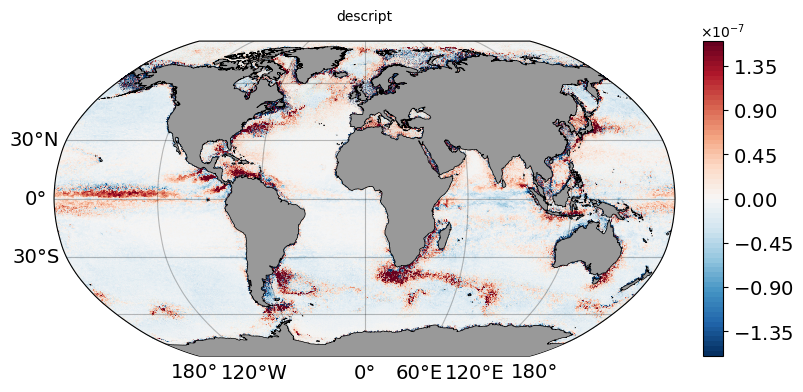

In [11]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.6e-7
cmax      = 1.6e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_48JFM-MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-JFM48.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1.6e-07, 'cmax': 1.6e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffe180352e0>, 'clevel': array([-1.60e-07, -1.55e-07, -1.50e-07, -1.45e-07, -1.40e-07, -1.35e-07,
       -1.30e-07, -1.25e-07, -1.20e-07, -1.15e-07, -1.10e-07, -1.05e-07,
       -1.00e-07, -9.50e-08, -9.00e-08, -8.50e-08, -8.00e-08, -7.50e-08,
       -7.00e-08, -6.50e-08, -6.00e-08, -5.50e-08, -5.00e-08, -4.50e-08,
       -4.00e-08, -3.50e-08, -3.00e-08, -2.50e-08, -2.00e-08, -1.50e-08,
       -1.00e-08, -5.00e-09,  0.00e+00,  5.00e-09,  1.00e-08,  1.50e-08,
        2.00e-08,  2.50e-08,  3.00e-08,  3.50e-08,  4.00e-08,  4.50e-08,
        5.00e-08,  5.50e-08,  6.00e-08,  6.50e-08,  7.00e-08,  7.50e-08,
        8.00e-08,  8.50e-08,  9.00e-08,  9.50e-08,  1.00e-07,  1.05e-07,
        1.10e-07,  1.15e-07,  1.20e-07,  1.25e-07,  1.30e-07,  1.35e-07,
        1.40e-07,  1.45e-07,  1.50e-07,  1.55

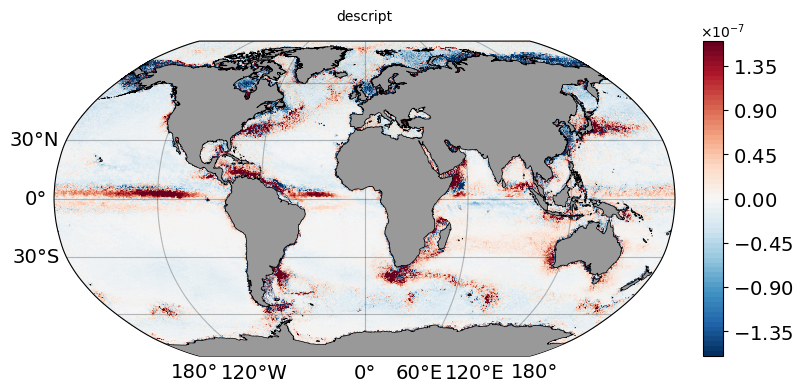

In [12]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.6e-7
cmax      = 1.6e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_48JAS-MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-JAS48.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1.6e-07, 'cmax': 1.6e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ff9f5babec0>, 'clevel': array([-1.60e-07, -1.55e-07, -1.50e-07, -1.45e-07, -1.40e-07, -1.35e-07,
       -1.30e-07, -1.25e-07, -1.20e-07, -1.15e-07, -1.10e-07, -1.05e-07,
       -1.00e-07, -9.50e-08, -9.00e-08, -8.50e-08, -8.00e-08, -7.50e-08,
       -7.00e-08, -6.50e-08, -6.00e-08, -5.50e-08, -5.00e-08, -4.50e-08,
       -4.00e-08, -3.50e-08, -3.00e-08, -2.50e-08, -2.00e-08, -1.50e-08,
       -1.00e-08, -5.00e-09,  0.00e+00,  5.00e-09,  1.00e-08,  1.50e-08,
        2.00e-08,  2.50e-08,  3.00e-08,  3.50e-08,  4.00e-08,  4.50e-08,
        5.00e-08,  5.50e-08,  6.00e-08,  6.50e-08,  7.00e-08,  7.50e-08,
        8.00e-08,  8.50e-08,  9.00e-08,  9.50e-08,  1.00e-07,  1.05e-07,
        1.10e-07,  1.15e-07,  1.20e-07,  1.25e-07,  1.30e-07,  1.35e-07,
        1.40e-07,  1.45e-07,  1.50e-07,  1.55

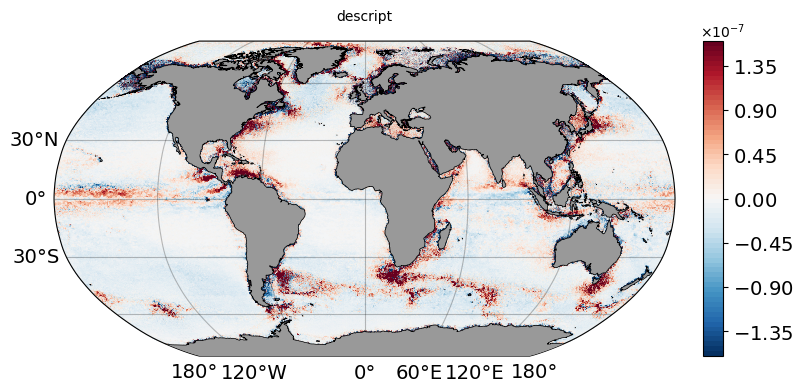

In [13]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.6e-7
cmax      = 1.6e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_50JFM-MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-JFM50.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1.6e-07, 'cmax': 1.6e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffe0342acf0>, 'clevel': array([-1.60e-07, -1.55e-07, -1.50e-07, -1.45e-07, -1.40e-07, -1.35e-07,
       -1.30e-07, -1.25e-07, -1.20e-07, -1.15e-07, -1.10e-07, -1.05e-07,
       -1.00e-07, -9.50e-08, -9.00e-08, -8.50e-08, -8.00e-08, -7.50e-08,
       -7.00e-08, -6.50e-08, -6.00e-08, -5.50e-08, -5.00e-08, -4.50e-08,
       -4.00e-08, -3.50e-08, -3.00e-08, -2.50e-08, -2.00e-08, -1.50e-08,
       -1.00e-08, -5.00e-09,  0.00e+00,  5.00e-09,  1.00e-08,  1.50e-08,
        2.00e-08,  2.50e-08,  3.00e-08,  3.50e-08,  4.00e-08,  4.50e-08,
        5.00e-08,  5.50e-08,  6.00e-08,  6.50e-08,  7.00e-08,  7.50e-08,
        8.00e-08,  8.50e-08,  9.00e-08,  9.50e-08,  1.00e-07,  1.05e-07,
        1.10e-07,  1.15e-07,  1.20e-07,  1.25e-07,  1.30e-07,  1.35e-07,
        1.40e-07,  1.45e-07,  1.50e-07,  1.55

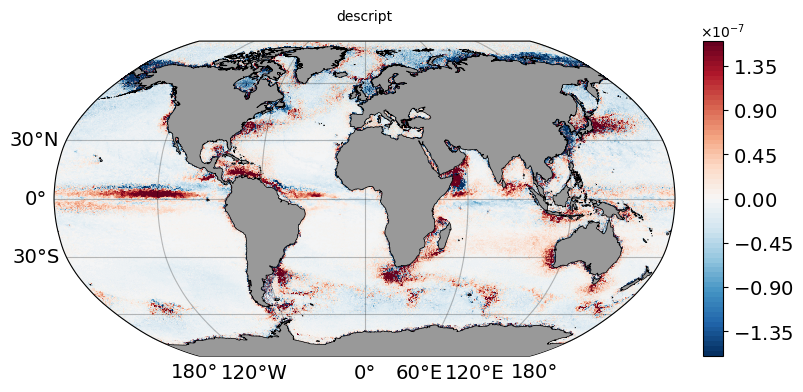

In [14]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.6e-7
cmax      = 1.6e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_50JAS-MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-JAS50.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

In [15]:
JFM4850 = (JFM50.WpRHOpH - JFM48.WpRHOpH
          ).to_dataset(name="WpRHOpH")
JAS4850 = (JAS50.WpRHOpH - JAS48.WpRHOpH
          ).to_dataset(name="WpRHOpH")
JFMJAS48 = (JFM48.WpRHOpH - JAS48.WpRHOpH
          ).to_dataset(name="WpRHOpH")
JFMJAS50 = (JFM50.WpRHOpH - JAS50.WpRHOpH
          ).to_dataset(name="WpRHOpH")

{'cstr': 'matplotlib.bwr', 'cnum': 41, 'cmin': -1e-07, 'cmax': 1e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffb45ccc830>, 'clevel': array([-1.00e-07, -9.75e-08, -9.50e-08, -9.25e-08, -9.00e-08, -8.75e-08,
       -8.50e-08, -8.25e-08, -8.00e-08, -7.75e-08, -7.50e-08, -7.25e-08,
       -7.00e-08, -6.75e-08, -6.50e-08, -6.25e-08, -6.00e-08, -5.75e-08,
       -5.50e-08, -5.25e-08, -5.00e-08, -4.75e-08, -4.50e-08, -4.25e-08,
       -4.00e-08, -3.75e-08, -3.50e-08, -3.25e-08, -3.00e-08, -2.75e-08,
       -2.50e-08, -2.25e-08, -2.00e-08, -1.75e-08, -1.50e-08, -1.25e-08,
       -1.00e-08, -7.50e-09, -5.00e-09, -2.50e-09,  0.00e+00,  2.50e-09,
        5.00e-09,  7.50e-09,  1.00e-08,  1.25e-08,  1.50e-08,  1.75e-08,
        2.00e-08,  2.25e-08,  2.50e-08,  2.75e-08,  3.00e-08,  3.25e-08,
        3.50e-08,  3.75e-08,  4.00e-08,  4.25e-08,  4.50e-08,  4.75e-08,
        5.00e-08,  5.25e-08,  5.50e-08,  5.75e-08,  

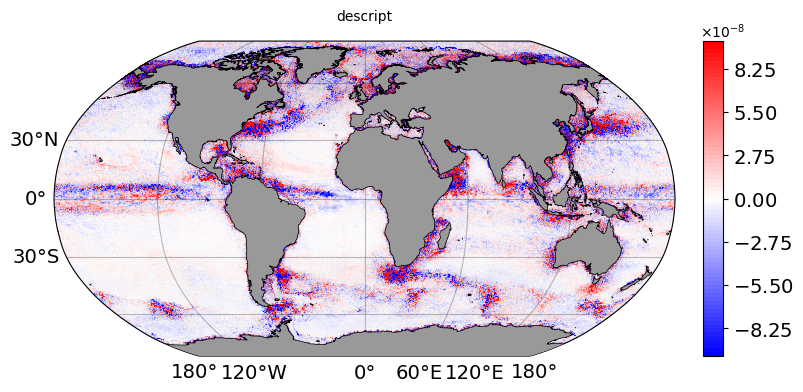

In [16]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.bwr'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.e-7
cmax      = 1.e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_50-48JAS_MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-JAS4850.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

{'cstr': 'matplotlib.bwr', 'cnum': 41, 'cmin': -1e-07, 'cmax': 1e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffe4ca00290>, 'clevel': array([-1.00e-07, -9.75e-08, -9.50e-08, -9.25e-08, -9.00e-08, -8.75e-08,
       -8.50e-08, -8.25e-08, -8.00e-08, -7.75e-08, -7.50e-08, -7.25e-08,
       -7.00e-08, -6.75e-08, -6.50e-08, -6.25e-08, -6.00e-08, -5.75e-08,
       -5.50e-08, -5.25e-08, -5.00e-08, -4.75e-08, -4.50e-08, -4.25e-08,
       -4.00e-08, -3.75e-08, -3.50e-08, -3.25e-08, -3.00e-08, -2.75e-08,
       -2.50e-08, -2.25e-08, -2.00e-08, -1.75e-08, -1.50e-08, -1.25e-08,
       -1.00e-08, -7.50e-09, -5.00e-09, -2.50e-09,  0.00e+00,  2.50e-09,
        5.00e-09,  7.50e-09,  1.00e-08,  1.25e-08,  1.50e-08,  1.75e-08,
        2.00e-08,  2.25e-08,  2.50e-08,  2.75e-08,  3.00e-08,  3.25e-08,
        3.50e-08,  3.75e-08,  4.00e-08,  4.25e-08,  4.50e-08,  4.75e-08,
        5.00e-08,  5.25e-08,  5.50e-08,  5.75e-08,  

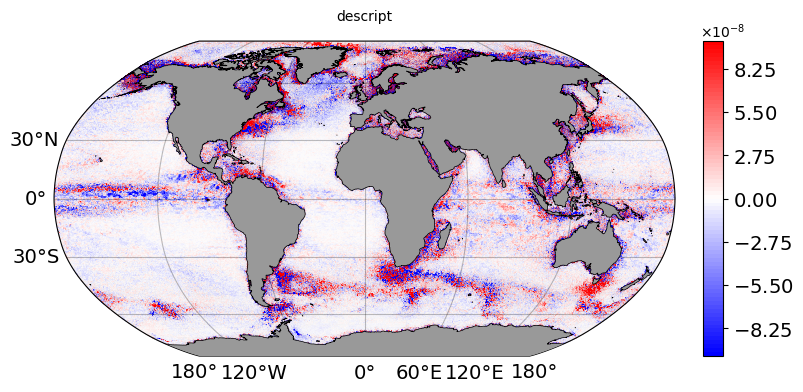

In [17]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.bwr'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.e-7
cmax      = 1.e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_50-48JFM_MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-JFM4850.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

{'cstr': 'matplotlib.bwr', 'cnum': 41, 'cmin': -1e-07, 'cmax': 1e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffe03dce450>, 'clevel': array([-1.00e-07, -9.75e-08, -9.50e-08, -9.25e-08, -9.00e-08, -8.75e-08,
       -8.50e-08, -8.25e-08, -8.00e-08, -7.75e-08, -7.50e-08, -7.25e-08,
       -7.00e-08, -6.75e-08, -6.50e-08, -6.25e-08, -6.00e-08, -5.75e-08,
       -5.50e-08, -5.25e-08, -5.00e-08, -4.75e-08, -4.50e-08, -4.25e-08,
       -4.00e-08, -3.75e-08, -3.50e-08, -3.25e-08, -3.00e-08, -2.75e-08,
       -2.50e-08, -2.25e-08, -2.00e-08, -1.75e-08, -1.50e-08, -1.25e-08,
       -1.00e-08, -7.50e-09, -5.00e-09, -2.50e-09,  0.00e+00,  2.50e-09,
        5.00e-09,  7.50e-09,  1.00e-08,  1.25e-08,  1.50e-08,  1.75e-08,
        2.00e-08,  2.25e-08,  2.50e-08,  2.75e-08,  3.00e-08,  3.25e-08,
        3.50e-08,  3.75e-08,  4.00e-08,  4.25e-08,  4.50e-08,  4.75e-08,
        5.00e-08,  5.25e-08,  5.50e-08,  5.75e-08,  

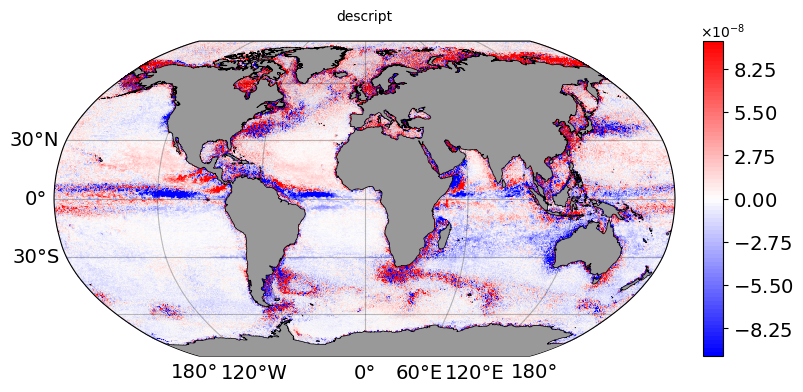

In [18]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.bwr'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.e-7
cmax      = 1.e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_48JFM-JAS_MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-JFMJAS48.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

{'cstr': 'matplotlib.bwr', 'cnum': 41, 'cmin': -1e-07, 'cmax': 1e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffbbb075d00>, 'clevel': array([-1.00e-07, -9.75e-08, -9.50e-08, -9.25e-08, -9.00e-08, -8.75e-08,
       -8.50e-08, -8.25e-08, -8.00e-08, -7.75e-08, -7.50e-08, -7.25e-08,
       -7.00e-08, -6.75e-08, -6.50e-08, -6.25e-08, -6.00e-08, -5.75e-08,
       -5.50e-08, -5.25e-08, -5.00e-08, -4.75e-08, -4.50e-08, -4.25e-08,
       -4.00e-08, -3.75e-08, -3.50e-08, -3.25e-08, -3.00e-08, -2.75e-08,
       -2.50e-08, -2.25e-08, -2.00e-08, -1.75e-08, -1.50e-08, -1.25e-08,
       -1.00e-08, -7.50e-09, -5.00e-09, -2.50e-09,  0.00e+00,  2.50e-09,
        5.00e-09,  7.50e-09,  1.00e-08,  1.25e-08,  1.50e-08,  1.75e-08,
        2.00e-08,  2.25e-08,  2.50e-08,  2.75e-08,  3.00e-08,  3.25e-08,
        3.50e-08,  3.75e-08,  4.00e-08,  4.25e-08,  4.50e-08,  4.75e-08,
        5.00e-08,  5.25e-08,  5.50e-08,  5.75e-08,  

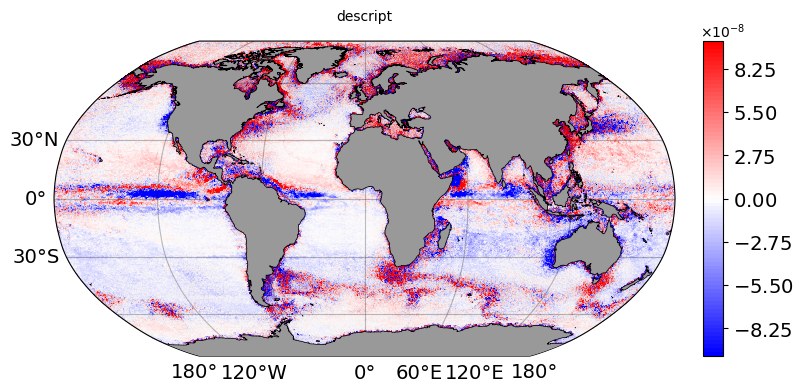

In [19]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.bwr'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.e-7
cmax      = 1.e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_50JFM-JAS_MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-JFMJAS50.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

In [ ]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.bwr'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.e-7
cmax      = 1.e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_48JAS-JFM_MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=JFMJAS48.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

In [ ]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.bwr'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1.e-7
cmax      = 1.e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_50JAS-JFM_MLD3.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=JFMJAS50.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  